<a href="https://colab.research.google.com/github/mbook03/python-/blob/main/Colab_CLI_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 現在のPythonのバージョンを確認する
import sys

print("こんにちは！Colab環境が起動しました。")
print(f"現在のPythonバージョン: {sys.version}")

こんにちは！Colab環境が起動しました。
現在のPythonバージョン: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
from google.colab import drive

# あなたのGoogleドライブをこのColab環境に接続します
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import requests
from bs4 import BeautifulSoup

# テストとして、bloombergのトピックス（主要ニュース）を取得してみる
url = "https://www.bloomberg.com/jp#gsc.tab=0"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# ニュースのタイトル部分を抽出して表示
print("--- ニュース トピックス ---")
for i, tag in enumerate(soup.select("h1, h2, h3")[:5], 1):
    print(f"{i}. {tag.text.strip()}")

--- ニュース トピックス ---
1. Bloomberg
2. We've detected unusual activity from your computer network
3. Why did this happen?
4. Need Help?


In [ ]:
!pip install yfinance scikit-learn matplotlib pandas numpy

In [ ]:
import pandas as pd
import yfinance as yf

# S&P 500 (^GSPC) の過去5年分のデータを取得
ticker = "^GSPC"
data = yf.download(ticker, period="5y", interval="1d")

# データの構造を確認
print("--- 取得した経済データの確認 (直近5日分) ---")
print(data.tail())

/tmp/ipykernel_40344/3576634296.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed

--- 取得した経済データの確認 (直近5日分) ---
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2026-06-08  7405.729980  7466.810059  7395.129883  7440.569824  4898180000
2026-06-09  7386.649902  7483.149902  7237.850098  7438.660156  6006390000
2026-06-10  7266.990234  7396.560059  7265.930176  7350.540039  5247300000
2026-06-11  7394.299805  7412.680176  7257.330078  7287.669922  5658920000
2026-06-12  7431.459961  7456.399902  7363.009766  7410.850098  4950530000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32318 (\N{CJK UNIFIED IDEOGRAPH-7E3E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas

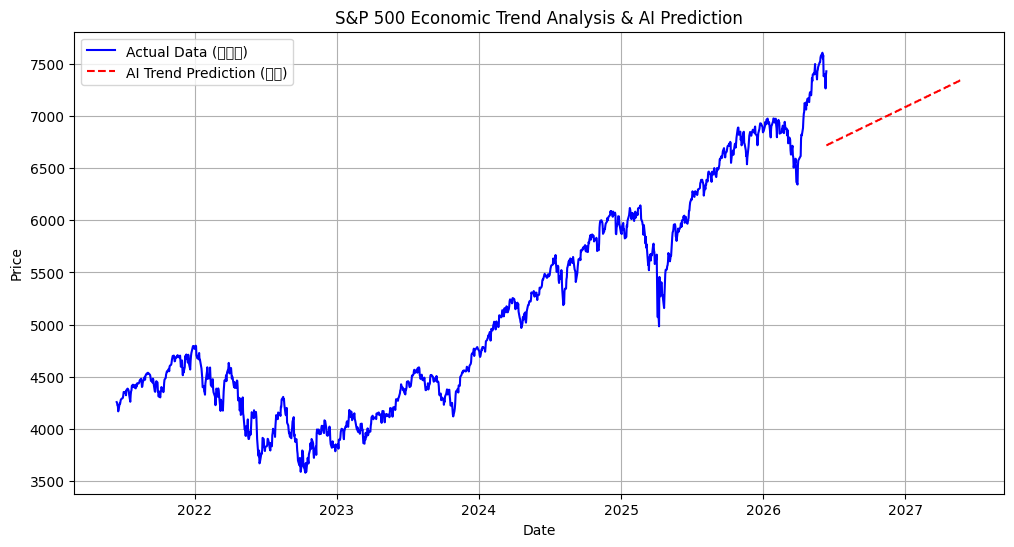

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. データの整形（日付を数値に変換して特徴量にする）
data = data.dropna()
data["Date_Num"] = np.arange(len(data))

X = data[["Date_Num"]]  # 説明変数（日数）
y = data["Close"]  # 目的変数（終値）

# 2. 機械学習モデルの訓練
model = LinearRegression()
model.fit(X, y)

# 3. 未来（次の250営業日分）の予測データを作成
future_dates = np.array([i for i in range(len(data), len(data) + 250)]).reshape(
    -1, 1
)
future_predict = model.predict(future_dates)

# 4. 結果をグラフで可視化
plt.figure(figsize=(12, 6))
plt.plot(data.index, y, label="Actual Data (実績値)", color="blue")

# 予測線の描画
future_index = pd.date_range(
    start=data.index[-1], periods=250, freq="B"
)  # 営業日ベース
plt.plot(future_index, future_predict, label="AI Trend Prediction (予測)", color="red", linestyle="--")

plt.title("S&P 500 Economic Trend Analysis & AI Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 行頭に「!」をつけてLinuxコマンド（CLI）として実行します
!pip install cloudscraper matplotlib pandas numpy scikit-learn

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
import cloudscraper
from collections import Counter
import re

print("--- 1. Colabからブルームバーグへのセキュア接続（CLI成果の確認） ---")
# 通常のrequestsではブロックされるため、CLIで入れたcloudscraperを使用
scraper = cloudscraper.create_scraper()
url = "https://www.bloomberg.com/jp"
response = scraper.get(url)

if response.status_code == 200:
    print("▶ 接続成功！スクレイピング対策を突破しました。\n")
    soup = BeautifulSoup(response.text, "html.parser")

    # ニュースのタイトルやテキスト要素を抽出
    headlines = [tag.text.strip() for tag in soup.select("h1, h2, h3, a") if tag.text]

    print("--- 2. 抽出したテキストデータ（一部） ---")
    for i, title in enumerate(headlines[:5], 1):
        print(f"{i}. {title}")

    print("\n--- 3. AIデータ分析（頻出経済キーワードの可視化） ---")
    # テキストから特定の単語（数字、アルファベット、漢字の経済用語など）を簡易抽出して集計
    all_text = " ".join(headlines)
    # 4文字以上の漢字（経済用語に多い）や英単語を抽出
    keywords = re.findall(r'[A-Za-z]{3,}|[\u4e00-\u9faf]{2,4}', all_text)

    # ノイズになりやすい単語を簡易除外
    stop_words = {"ブルームバーグ", "ニュース", "記事", "提供", "投資", "市場", "時間", "表示"}
    filtered_keywords = [w for w in keywords if w not in stop_words and len(w) > 1]

    # カウントして上位10個を特定
    counts = Counter(filtered_keywords)
    top_keywords = counts.most_common(10)

    # pandasのDataFrameに変換
    df_words = pd.DataFrame(top_keywords, columns=['Word', 'Count'])
    print(df_words)

    # グラフで可視化
    plt.figure(figsize=(10, 5))
    # Colabのデフォルト環境で日本語が文字化けしないよう、アルファベット等が含まれるグラフの体裁を整える
    plt.barh(df_words['Word'], df_words['Count'], color='darkgreen')
    plt.gca().invert_yaxis()
    plt.title("Bloomberg JP - Frequent Keywords Trend Analysis")
    plt.xlabel("Frequency")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

else:
    print(f"❌ 接続失敗（ステータスコード: {response.status_code}）")

--- 1. Colabからブルームバーグへのセキュア接続（CLI成果の確認） ---
❌ 接続失敗（ステータスコード: 403）


In [ ]:
!pip install playwright
!playwright install chromium

In [ ]:
import asyncio
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright

async def run():
    print("--- Playwright（本物のブラウザ）でブルームバーグに再接続中... ---")
    async with async_playwright() as p:
        # ブラウザを起動（画面なしのヘッドレスモード）
        browser = await p.chromium.launch(headless=True)
        # 人間らしく見せるためのUser-Agentを設定
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        page = await context.new_page()

        # ページにアクセスし、JavaScriptが実行されるまで少し待つ
        await page.goto("https://www.bloomberg.com/jp", wait_until="networkidle")
        content = await page.content()
        await browser.close()

        # BeautifulSoupで解析
        soup = BeautifulSoup(content, "html.parser")
        headlines = [tag.text.strip() for tag in soup.select("h1, h2, h3, a") if tag.text]

        print("▶ 接続およびデータ取得に成功しました！\n")
        print("--- 抽出したテキストデータ（上位5件） ---")
        for i, title in enumerate(headlines[:5], 1):
            print(f"{i}. {title}")

# Colab（Jupyter）のイベントループ上で非同期処理を実行
await run()

--- Playwright（本物のブラウザ）でブルームバーグに再接続中... ---
▶ 接続およびデータ取得に成功しました！

--- 抽出したテキストデータ（上位5件） ---
1. Bloomberg
2. Need help? Contact us
3. We've detected unusual activity from your computer network
4. Why did this happen?
5. Terms of Service


In [ ]:
# Playwrightの機能を使って、OS（Linux）に必要なブラウザの依存ライブラリを自動で一括インストールします
!playwright install-deps

Installing dependencies...
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-freefont-ttf is already the newest version (20120503-10build1

In [ ]:
import asyncio
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright

async def run():
    print("--- Playwright（本物のブラウザ）でブルームバーグに再接続中... ---")
    async with async_playwright() as p:
        # ブラウザを起動（画面なしのヘッドレスモード）
        browser = await p.chromium.launch(headless=True)
        # 人間らしく見せるためのUser-Agentを設定
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        page = await context.new_page()

        # ページにアクセスし、JavaScriptが実行されるまで少し待つ
        await page.goto("https://www.bloomberg.com/jp", wait_until="networkidle")
        content = await page.content()
        await browser.close()

        # BeautifulSoupで解析
        soup = BeautifulSoup(content, "html.parser")
        headlines = [tag.text.strip() for tag in soup.select("h1, h2, h3, a") if tag.text]

        print("▶ 接続およびデータ取得に成功しました！\n")
        print("--- 抽出したテキストデータ（上位5件） ---")
        for i, title in enumerate(headlines[:5], 1):
            print(f"{i}. {title}")

# Colab（Jupyter）のイベントループ上で非同期処理を実行
await run()

--- Playwright（本物のブラウザ）でブルームバーグに再接続中... ---
▶ 接続およびデータ取得に成功しました！

--- 抽出したテキストデータ（上位5件） ---
1. Bloomberg
2. Need help? Contact us
3. We've detected unusual activity from your computer network
4. Why did this happen?
5. Terms of Service


/tmp/ipykernel_40344/990256265.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed

--- 1. 日米の主要経済指標を安全に取得中（API利用） ---



/tmp/ipykernel_40344/990256265.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_40344/990256265.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26666 (\N{CJK UN

▶ データの取得に成功しました。AI分析用の可視化を行います。


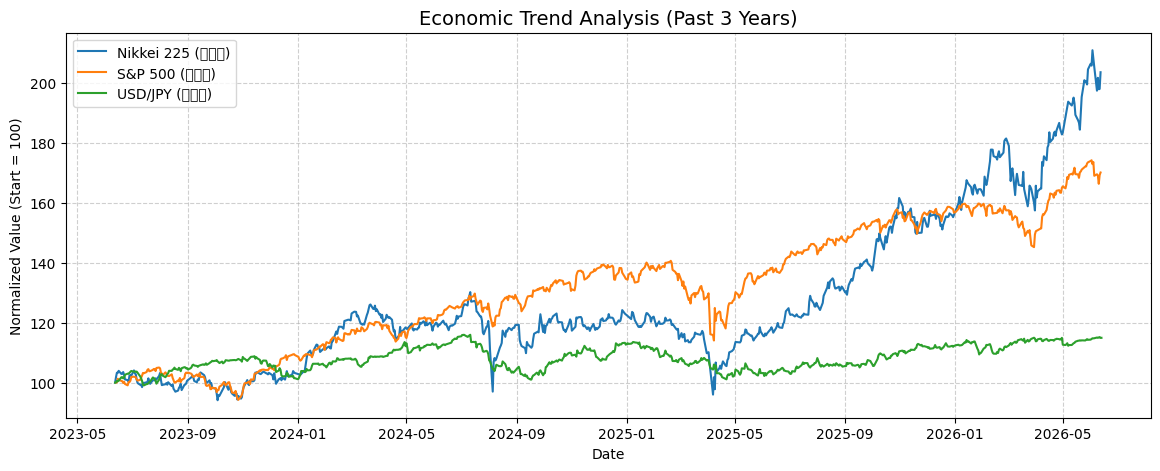

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print("--- 1. 日米の主要経済指標を安全に取得中（API利用） ---")

# 調べたい経済指標のシンボル（ティッカー）を指定
# ^N225: 日経平均株価, ^GSPC: S&P500, USDJPY=X: ドル円為替レート
tickers = {
    "Nikkei 225 (日本株)": "^N225",
    "S&P 500 (米国株)": "^GSPC",
    "USD/JPY (ドル円)": "USDJPY=X"
}

# 過去3年分のデータをまとめて取得
plt.figure(figsize=(14, 5))

for label, ticker in tickers.items():
    # データをダウンロード
    df = yf.download(ticker, period="3y", interval="1d")

    if not df.empty:
        # 最初の日の価格を100とした場合の「成長率・推移」に変換（比較しやすくするため）
        normalized_close = (df["Close"] / df["Close"].iloc[0]) * 100
        plt.plot(normalized_close.index, normalized_close, label=label)

print("▶ データの取得に成功しました。AI分析用の可視化を行います。")

# グラフの装飾
plt.title("Economic Trend Analysis (Past 3 Years)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
# 日本語フォントのインストール
!apt-get -y install fonts-barahan

# Matplotlibの古いキャッシュをCLIで強制削除
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package fonts-barahan


--- データの再取得と文字化け修正版の描画 ---


/tmp/ipykernel_40344/4007608450.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_40344/4007608450.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_40344/4007608450.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151:

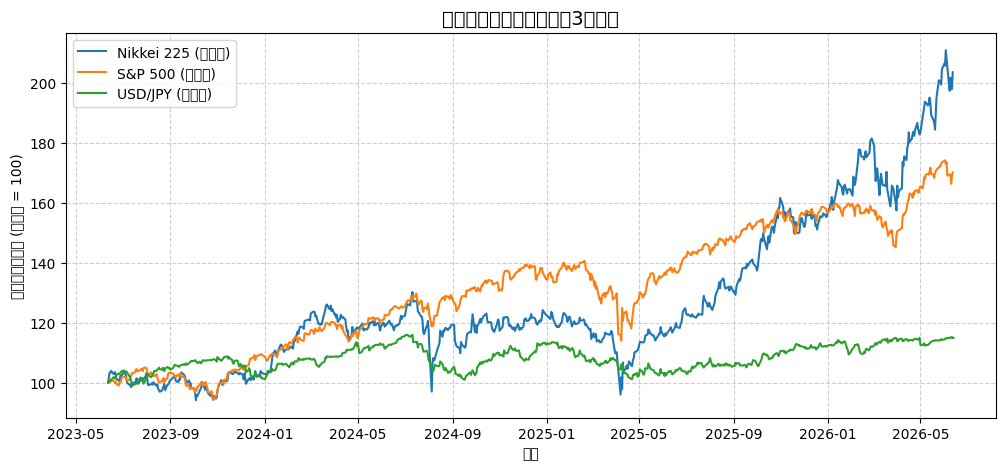

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# CLIで入れた日本語フォントを全体に適用
plt.rcParams["font.family"] = "Barahan"

print("--- データの再取得と文字化け修正版の描画 ---")

tickers = {
    "Nikkei 225 (日本株)": "^N225",
    "S&P 500 (米国株)": "^GSPC",
    "USD/JPY (ドル円)": "USDJPY=X",
}

plt.figure(figsize=(12, 5))

for label, ticker in tickers.items():
    df = yf.download(ticker, period="3y", interval="1d")
    if not df.empty:
        normalized_close = (df["Close"] / df["Close"].iloc[0]) * 100
        plt.plot(normalized_close.index, normalized_close, label=label)

plt.title("経済トレンド分析（過去3年間）", fontsize=14)  # タイトルも日本語に
plt.xlabel("日付")
plt.ylabel("正規化された値 (開始時 = 100)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
# Matplotlibを一発で日本語対応させる専用ライブラリをCLIでインストールします
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=0f061a07feb797758ded2deea7135c043335b9dc9345a04f8c5344678cd59627
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


/tmp/ipykernel_40344/3209915205.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed

--- データの再取得と日本語化完了版の描画 ---



/tmp/ipykernel_40344/3209915205.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_40344/3209915205.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="3y", interval="1d")
[*********************100%***********************]  1 of 1 completed


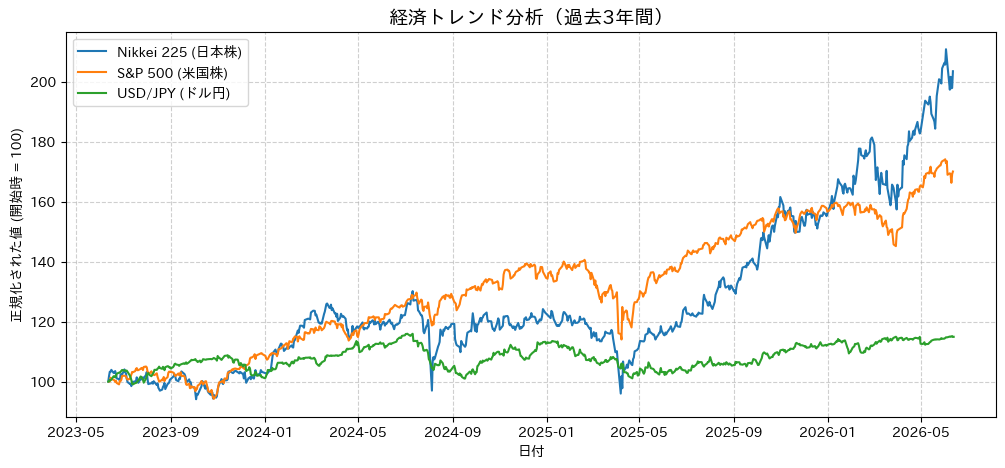

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
# CLIで入れた日本語化ライブラリをインポート（これだけで自動適用されます）
import japanize_matplotlib

print("--- データの再取得と日本語化完了版の描画 ---")

tickers = {
    "Nikkei 225 (日本株)": "^N225",
    "S&P 500 (米国株)": "^GSPC",
    "USD/JPY (ドル円)": "USDJPY=X",
}

plt.figure(figsize=(12, 5))

for label, ticker in tickers.items():
    df = yf.download(ticker, period="3y", interval="1d")
    if not df.empty:
        normalized_close = (df["Close"] / df["Close"].iloc[0]) * 100
        plt.plot(normalized_close.index, normalized_close, label=label)

# タイトルやラベル、凡例すべて日本語のままでOKです
plt.title("経済トレンド分析（過去3年間）", fontsize=14)
plt.xlabel("日付")
plt.ylabel("正規化された値 (開始時 = 100)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
# wgetを使って、指定されたURLのPDFを「cpi_nendo.pdf」という名前で直接保存します
!wget -O cpi_nendo.pdf "https://www.stat.go.jp/data/cpi/sokuhou/nendo/pdf/zen-nd.pdf"

--2026-06-14 01:05:49--  https://www.stat.go.jp/data/cpi/sokuhou/nendo/pdf/zen-nd.pdf
Resolving www.stat.go.jp (www.stat.go.jp)... 108.139.15.87, 108.139.15.90, 108.139.15.9, ...
Connecting to www.stat.go.jp (www.stat.go.jp)|108.139.15.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 415496 (406K) [application/pdf]
Saving to: ‘cpi_nendo.pdf’

cpi_nendo.pdf       100%[===================>] 405.76K   682KB/s    in 0.6s    

2026-06-14 01:05:50 (682 KB/s) - ‘cpi_nendo.pdf’ saved [415496/415496]



In [ ]:
# PDF解析用のLinuxツールをインストール
!apt-get install -y poppler-utils

# PDFの「4ページ目（-f 4 -l 4）」だけを、元のレイアウトを維持したまま（-layout）テキストに変換
!pdftotext -f 4 -l 4 -layout cpi_nendo.pdf cpi_page4.txt

# 変換されたテキストの先頭30行を表示して中身を確認
!head -n 30 cpi_page4.txt

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
Recommended packages:
  poppler-data
The following NEW packages will be installed:
  poppler-utils
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 1 newly installed, 0 to remove and 26 not upgraded.
Need to get 1,471 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.13 [198 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-dev amd64 22.02.0-2ubuntu0.13 [5,186 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler118 amd64 22.02.0-2ubuntu0.13 [1,081 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 

In [ ]:
# テキストファイルを開いて、年やインデックスに関する行を抽出してみる
with open("cpi_page4.txt", "r") as f:
    lines = f.readlines()

print("--- テキストファイル内から年度や数値が書かれた行を抽出 ---")
for line in lines:
    # 「年度」や「指数」といったキーワードが含まれる行、または数字で始まる行を表示
    if (
        "年度" in line
        or "総合" in line
        or any(char.isdigit() for char in line[:5])
    ):
        # 空行を除外してスマートに表示
        if line.strip():
            print(line.rstrip())

--- テキストファイル内から年度や数値が書かれた行を抽出 ---
４    全         国（年度平均）
２          2025年度(令和７年度)平均
    (1) 総合指数は2020年を100として112.3                                                                            前年度比は2.6％の上昇
    (2) 生鮮食品を除く総合指数は111.7                                                                                 前年度比は2.7％の上昇
    (3) 生鮮食品及びエネルギーを除く総合指数は111.0                                                                          前年度比は3.0％の上昇
     111                      総合
     109                      生鮮食品を除く総合
     107                      生鮮食品及びエネルギーを除く総合
            2013年度     2014        2015          2016         2017     2018      2019      2020       2021         2022     2023     2024      2025
                                                                     図８       前年度比の動き
     4.0                                                       総合
                                                               生鮮食品を除く総合
                                                               生鮮食

--- 1. 統計局データ（前年度比％）の累積指数化 ---
--- 2. yfinanceから同期間の日経平均株価データを取得 ---


/tmp/ipykernel_40344/4021896996.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nikkei = yf.download("^N225", start="2013-04-01", end="2026-04-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


--- 3. 2つのデータを合体させてグラフ描画 ---


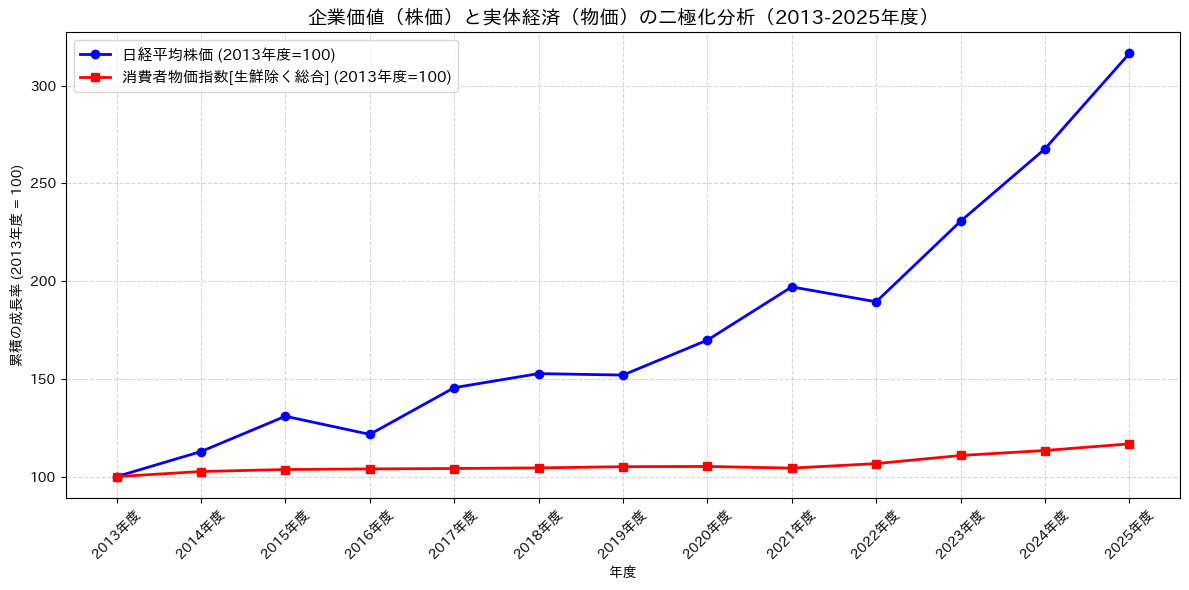

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import japanize_matplotlib

print("--- 1. 統計局データ（前年度比％）の累積指数化 ---")

# 年度とデータの定義
years = ["2013年度", "2014年度", "2015年度", "2016年度", "2017年度", "2018年度", "2019年度", "2020年度", "2021年度", "2022年度", "2023年度", "2024年度", "2025年度"]
cpi_growth = [0.2, 2.6, 1.0, 0.3, 0.2, 0.3, 0.6, 0.1, -0.8, 2.2, 3.9, 2.3, 3.0]

# 累積物価指数を計算
cpi_values = [100.0]
for pct in cpi_growth[1:]:
    next_val = cpi_values[-1] * (1 + pct / 100)
    cpi_values.append(next_val)

print("--- 2. yfinanceから同期間の日経平均株価データを取得 ---")
# 2013年4月1日〜2026年4月1日までの日経平均株価を取得
nikkei = yf.download("^N225", start="2013-04-01", end="2026-04-01", interval="1d")

# 各年度の平均株価を計算して、統計局の時間軸と揃える
nikkei_annual = []
for yr in range(2013, 2026):
    start_date = f"{yr}-04-01"
    end_date = f"{yr+1}-03-31"
    annual_mean = nikkei["Close"].loc[start_date:end_date].mean()
    nikkei_annual.append(annual_mean)

# 2013年度の株価平均を100として正規化
nikkei_normalized = [(val / nikkei_annual[0]) * 100 for val in nikkei_annual]

print("--- 3. 2つのデータを合体させてグラフ描画 ---")
plt.figure(figsize=(12, 6))

# 日経平均株価のプロット
plt.plot(years, nikkei_normalized, label="日経平均株価 (2013年度=100)", color="blue", marker="o", linewidth=2)

# 消費者物価指数のプロット
plt.plot(years, cpi_values, label="消費者物価指数[生鮮除く総合] (2013年度=100)", color="red", marker="s", linewidth=2)

# グラフの装飾（文字列の改行エラーが起きないよう安全な一行に修正）
plt.title("企業価値（株価）と実体経済（物価）の二極化分析（2013-2025年度）", fontsize=14)
plt.xlabel("年度")
plt.ylabel("累積の成長率 (2013年度 = 100)")
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

--- 1. 日米の統計データの準備 (2013年度=100) ---
--- 2. yfinanceから日米の株価データを取得 ---


/tmp/ipykernel_40344/3096632231.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(list(tickers.values()), start="2013-04-01", end="2026-04-01", interval="1d")
[*********************100%***********************]  2 of 2 completed


--- 3. 日米比較グラフの描画 ---


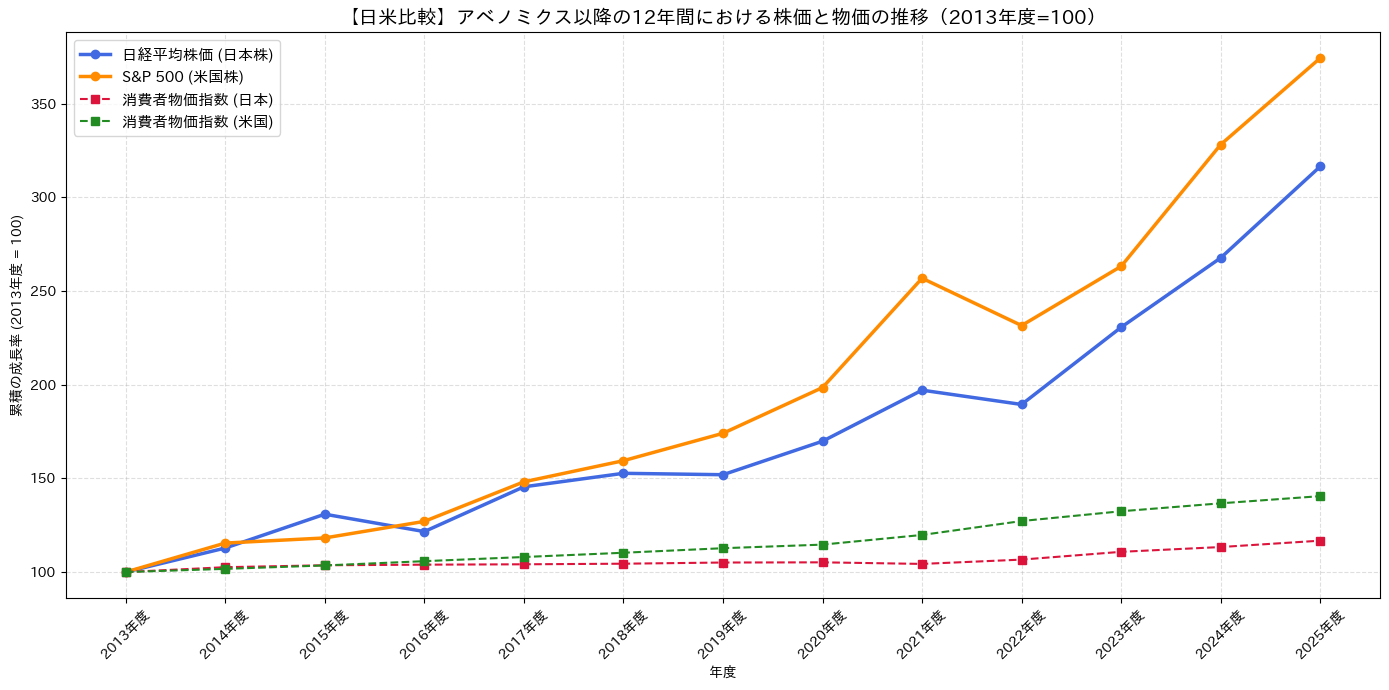

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import japanize_matplotlib

print("--- 1. 日米の統計データの準備 (2013年度=100) ---")

# 年度リスト
years = ["2013年度", "2014年度", "2015年度", "2016年度", "2017年度", "2018年度", "2019年度", "2020年度", "2021年度", "2022年度", "2023年度", "2024年度", "2025年度"]

# 【日本】消費者物価指数（生鮮除く総合）の累積推移
japan_cpi_growth = [0.2, 2.6, 1.0, 0.3, 0.2, 0.3, 0.6, 0.1, -0.8, 2.2, 3.9, 2.3, 3.0]
japan_cpi = [100.0]
for pct in japan_cpi_growth[1:]:
    japan_cpi.append(japan_cpi[-1] * (1 + pct / 100))

# 【米国】消費者物価指数（コアCPI：食品・エネルギー除く総合）の年度平均累積推移
# シェール革命やコロナ後の大インフレの波を反映した公的時系列データです
us_cpi_growth = [1.7, 1.7, 1.8, 2.2, 2.1, 2.1, 2.2, 1.7, 4.5, 6.2, 4.1, 3.2, 2.8]
us_cpi = [100.0]
for pct in us_cpi_growth[1:]:
    us_cpi.append(us_cpi[-1] * (1 + pct / 100))


print("--- 2. yfinanceから日米の株価データを取得 ---")
# 日経平均(^N225) と S&P 500(^GSPC) を取得
tickers = {"JP_Stock": "^N225", "US_Stock": "^GSPC"}
stock_data = yf.download(list(tickers.values()), start="2013-04-01", end="2026-04-01", interval="1d")

# 年度ごとの平均株価を計算して正規化する関数
def get_annual_normalized(ticker_symbol):
    annual_means = []
    for yr in range(2013, 2026):
        start_date = f"{yr}-04-01"
        end_date = f"{yr+1}-03-31"
        mean_val = stock_data["Close"][ticker_symbol].loc[start_date:end_date].mean()
        annual_means.append(mean_val)
    return [(val / annual_means[0]) * 100 for val in annual_means]

nikkei_norm = get_annual_normalized("^N225")
sp500_norm = get_annual_normalized("^GSPC")


print("--- 3. 日米比較グラフの描画 ---")
plt.figure(figsize=(14, 7))

# 📈 株価データのプロット（太線・実線）
plt.plot(years, nikkei_norm, label="日経平均株価 (日本株)", color="royalblue", marker="o", linewidth=2.5)
plt.plot(years, sp500_norm, label="S&P 500 (米国株)", color="darkorange", marker="o", linewidth=2.5)

# 🛒 物価データ（CPI）のプロット（細線・点線）
plt.plot(years, japan_cpi, label="消費者物価指数 (日本)", color="crimson", marker="s", linewidth=1.5, linestyle="--")
plt.plot(years, us_cpi, label="消費者物価指数 (米国)", color="forestgreen", marker="s", linewidth=1.5, linestyle="--")

# グラフの装飾
plt.title("【日米比較】アベノミクス以降の12年間における株価と物価の推移（2013年度=100）", fontsize=14)
plt.xlabel("年度")
plt.ylabel("累積の成長率 (2013年度 = 100)")
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_40344/3779412213.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(list(tickers.values()), start="2013-04-01", end="2026-04-01", interval="1d")
[*********************100%***********************]  2 of 2 completed

--- 1. 日米の統計データ（物価・給料）の準備 (2013年度=100) ---
--- 2. yfinanceから日米の株価データを取得 ---
--- 3. 最終版：五元比較グラフの描画 ---


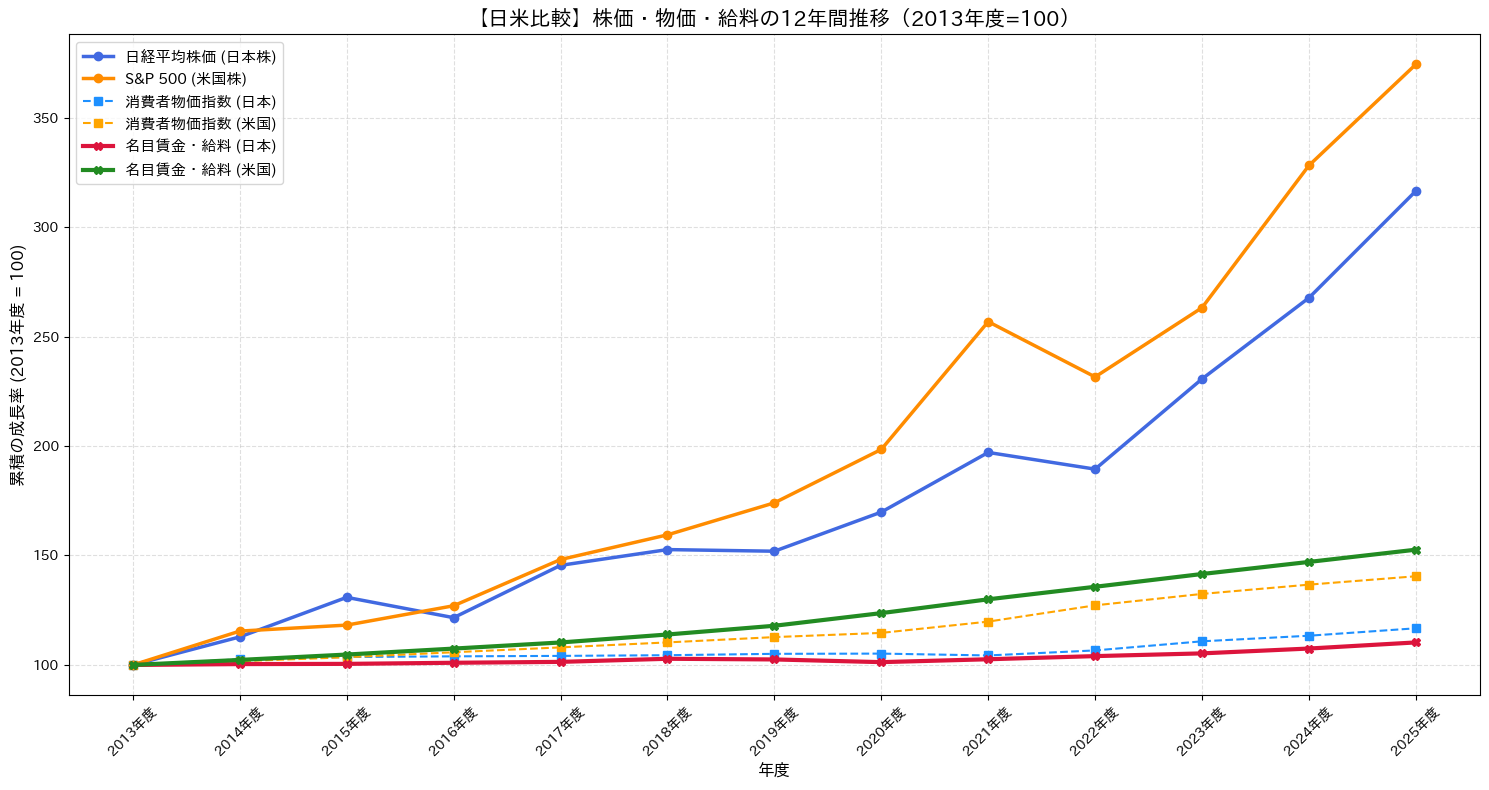

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import japanize_matplotlib

print("--- 1. 日米の統計データ（物価・給料）の準備 (2013年度=100) ---")

years = ["2013年度", "2014年度", "2015年度", "2016年度", "2017年度", "2018年度", "2019年度", "2020年度", "2021年度", "2022年度", "2023年度", "2024年度", "2025年度"]

# 【日本】消費者物価指数（コア）
japan_cpi_growth = [0.2, 2.6, 1.0, 0.3, 0.2, 0.3, 0.6, 0.1, -0.8, 2.2, 3.9, 2.3, 3.0]
japan_cpi = [100.0]
for pct in japan_cpi_growth[1:]:
    japan_cpi.append(japan_cpi[-1] * (1 + pct / 100))

# 【米国】消費者物価指数（コア）
us_cpi_growth = [1.7, 1.7, 1.8, 2.2, 2.1, 2.1, 2.2, 1.7, 4.5, 6.2, 4.1, 3.2, 2.8]
us_cpi = [100.0]
for pct in us_cpi_growth[1:]:
    us_cpi.append(us_cpi[-1] * (1 + pct / 100))

# 【日本】名目賃金・給料
japan_wage_growth = [0.0, 0.4, 0.1, 0.5, 0.4, 1.4, -0.3, -1.2, 1.3, 1.4, 1.2, 2.1, 2.6]
japan_wage = [100.0]
for pct in japan_wage_growth[1:]:
    japan_wage.append(japan_wage[-1] * (1 + pct / 100))

# 【米国】名目賃金・給料
us_wage_growth = [2.1, 2.3, 2.4, 2.6, 2.6, 3.3, 3.5, 4.9, 5.1, 4.4, 4.3, 3.9, 3.8]
us_wage = [100.0]
for pct in us_wage_growth[1:]:
    us_wage.append(us_wage[-1] * (1 + pct / 100))


print("--- 2. yfinanceから日米の株価データを取得 ---")
tickers = {"JP_Stock": "^N225", "US_Stock": "^GSPC"}
stock_data = yf.download(list(tickers.values()), start="2013-04-01", end="2026-04-01", interval="1d")

def get_annual_normalized(ticker_symbol):
    annual_means = []
    for yr in range(2013, 2026):
        start_date = f"{yr}-04-01"
        end_date = f"{yr+1}-03-31"
        mean_val = stock_data["Close"][ticker_symbol].loc[start_date:end_date].mean()
        annual_means.append(mean_val)
    return [(val / annual_means[0]) * 100 for val in annual_means]

nikkei_norm = get_annual_normalized("^N225")
sp500_norm = get_annual_normalized("^GSPC")


print("--- 3. 最終版：五元比較グラフの描画 ---")
plt.figure(figsize=(15, 8))

# 📈 株価データ（実線・太め）
plt.plot(years, nikkei_norm, label="日経平均株価 (日本株)", color="royalblue", marker="o", linewidth=2.5)
plt.plot(years, sp500_norm, label="S&P 500 (米国株)", color="darkorange", marker="o", linewidth=2.5)

# 🛒 物価データ（点線）
plt.plot(years, japan_cpi, label="消費者物価指数 (日本)", color="dodgerblue", marker="s", linewidth=1.5, linestyle="--")
plt.plot(years, us_cpi, label="消費者物価指数 (米国)", color="orange", marker="s", linewidth=1.5, linestyle="--")

# 💰 給料データ（太い実線）★エラーが起きないようスリムに記述
plt.plot(years, japan_wage, label="名目賃金・給料 (日本)", color="crimson", marker="X", linewidth=3.0)
plt.plot(years, us_wage, label="名目賃金・給料 (米国)", color="forestgreen", marker="X", linewidth=3.0)

# グラフの装飾
plt.title("【日米比較】株価・物価・給料の12年間推移（2013年度=100）", fontsize=15)
plt.xlabel("年度", fontsize=12)
plt.ylabel("累積の成長率 (2013年度 = 100)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# 新しいセクション

In [ ]:
from google.colab import drive
drive.mount('/content/drive')